# FAIR-TRACE / SCAFF — the planted-sensitivity localization experiment, made robust

**Run this notebook top to bottom in Colab.** It is fully self-contained: `numpy` + `pandas` +
`matplotlib`, all preinstalled, **no API key, no LangChain, no LLM**. The full configuration
takes a few minutes; set `QUICK = True` in §1 for a ~1-minute smoke run.

## Why this notebook exists

The 2026-08-16 prototype reports that the SCAFF stage crossover localizes a planted attribute
dependence with **100% accuracy**, and that repairing the implicated stage removes the downstream
disparity. Both claims are load-bearing for the paper, and neither survives contact with four
defects found while reproducing them. Before a real dataset is attached, the instrument itself has
to be trustworthy — otherwise the dataset is being measured with a ruler whose noise exceeds the
effect it reports.

| # | Defect in the prototype | What this notebook does instead | § |
|---|---|---|---|
| ① | Rank's `top1_gap` coordinate has a repeat-noise floor (0.328) **larger** than the direct effect it estimates (0.094), and being 0/1 it is blind to a true effect that does not move the top item | Five graded rank distances compared on effect size, residual floor, separation and detection AUC on identical trajectories; the winner is chosen by that table, not by hand | §7, §9 |
| ② | Repair removability is **circular**: the final divergence measure *is* the Rank distance, so pasting in the counterpart arm's ranked list zeroes it by construction, whatever the true fault | Score strictly **downstream** of the repaired stage; report the full planted × repaired matrix, with the circular scoring kept alongside so the defect shows a number | §10 |
| ③ | "100% localization" has no interval, and came from 48 scenarios at one seed | Bootstrap + Wilson intervals on the accuracy, bootstrap CIs beside **every** coordinate point estimate, and a five-seed sweep reporting the across-seed spread | §9 |
| ④ | The detection margin $\tau = 0.10$ is hand-set | $\tau$ calibrated from the control scenarios' own noise distribution as a false-positive budget, plus a full sweep with precision–recall and ROC curves | §8 |

Plus one reporting distinction the prototype conflated: a fault planted at **Explain or Memory
cannot move a single-turn endpoint at all**, because both stages sit downstream of the ranked list.
That is *structural blindness*, not low statistical power — a stronger claim, but only if the two
are reported separately (§11).

## What is new here relative to the 0819 run

The 0819 notebook imports a local module and so cannot run in Colab. Beyond making everything
runnable in one file, this notebook adds four things that were specified but not implemented:

1. an explicit **structural validity gate** $\Sigma_s$ — every stage output is checked for shape
   and referential integrity before any fairness quantity is computed, and an invalid pair is
   *excluded*, never scored as a zero (§4);
2. **bootstrap confidence intervals beside every coordinate**, not only beside the headline
   accuracy (§9);
3. **precision–recall and ROC curves** over $\tau$, rather than a single accuracy trace (§8);
4. the **across-seed spread of the coordinate table** itself, not just of the accuracy (§9);

and an executable **containment proof** that no stage observes the protected descriptor except
through the planted fault (§3).

## Scope — please keep this with every table

> The planted faults are **unit tests of the measurement instrument**. They are not estimates of
> real-world disparity and assert nothing whatsoever about the preferences, behaviour or treatment
> of any group. No ground truth is manufactured with an LLM judge: where no defensible oracle
> $\Omega_s$ exists, harm is reported as **not identified**.

## Notation (matching `main_yd.tex`)

Each stage $s$ contributes three coordinates plus a noise term, from the $2\times2$ crossover
$Y_s^{i,j} = \phi_s\!\left(f_s(Z_s^i, A{=}j; \varepsilon)\right)$ over parent state $Z_s$ and
protected descriptor $A$:

$$D_s^{\mathrm{nat}} = \mathrm{d}_s\!\left(Y_s^{a,a},\, Y_s^{a',a'}\right)$$
$$D_s^{A} = \tfrac12\left[\mathrm{d}_s\!\left(Y_s^{a,a}, Y_s^{a,a'}\right) + \mathrm{d}_s\!\left(Y_s^{a',a}, Y_s^{a',a'}\right)\right] \qquad\text{(hold } Z_s\text{, swap } A\text{)}$$
$$D_s^{Z} = \tfrac12\left[\mathrm{d}_s\!\left(Y_s^{a,a}, Y_s^{a',a}\right) + \mathrm{d}_s\!\left(Y_s^{a,a'}, Y_s^{a',a'}\right)\right] \qquad\text{(hold } A\text{, swap } Z_s\text{)}$$

The framework's question is *where dependence enters* — $D^A$ (direct) versus $D^Z$ (inherited) —
not whether each stage differs.

## 1. Setup and configuration

The configuration is fixed here rather than passed in, so that "re-run it and the numbers match"
is a meaningful check. `QUICK = True` shrinks the corpus and the bootstrap for a fast pass; it
changes the numbers and is for smoke-testing only.

In [1]:
import itertools, json, math, pathlib, sys, time, zlib
from typing import Dict, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 4)

IN_COLAB = "google.colab" in sys.modules

# ------------------------------------------------------------------ configuration
QUICK = False          # True -> ~1 min smoke run (different numbers); False -> paper config

N_PER_STAGE = 6 if QUICK else 20        # scenarios per condition; 6 conditions (5 stages + none)
REPEATS     = 4 if QUICK else 8         # repeats per scenario, for the noise coordinate
SEEDS       = [42, 43] if QUICK else [42, 43, 44, 45, 46]
BOOT        = 500 if QUICK else 4000    # bootstrap resamples
DEFAULT_SEED = 42

STAGES      = ["Elicit", "Retrieve", "Rank", "Explain", "Memory"]
DESCRIPTORS = ("man", "woman")
TOP_K       = 5
GENRES      = ["mystery", "scifi", "comedy", "drama"]
TONES       = ["cerebral", "romantic", "playful"]

# Stochasticity. Tuned so this substrate sits in the shared run's regime rather than matching it
# exactly (one domain, not two; a larger catalog). The defect has to be *reproduced* before it can
# be shown fixed, and a deterministic substrate has no noise floor to study at all.
RANK_JITTER   = 0.10   # gaussian score jitter at Rank
RETRIEVE_TEMP = 0.06   # Gumbel temperature on the popularity order at Retrieve

LEGACY_MARGIN   = 0.10           # the hand-set tau this work replaces
LEGACY_METRIC   = "top1_gap"     # the prototype's Rank coordinate
PRIMARY_METRIC  = "ndcg_delta"   # chosen in §6 by the comparison table, not by hand
ENDPOINT_MARGIN = 0.02

# Write next to the paper if we are in the repo; otherwise into the working directory. The
# filenames deliberately differ from the 0819 pipeline's, so a Colab run never silently
# overwrites an artifact the .tex already cites.
OUT_DIR = pathlib.Path("paper") if pathlib.Path("paper").is_dir() else pathlib.Path(".")
OUT_JSON = OUT_DIR / "scaff_robustness_colab_results.json"
OUT_FIG = OUT_DIR / "figures" / "fig_scaff_robustness_colab"
RESULTS = {}   # every paper-bound number is accumulated here and dumped in §11

print(f"colab={IN_COLAB}  quick={QUICK}  numpy={np.__version__}  pandas={pd.__version__}")
print(f"corpus: {N_PER_STAGE} x 6 = {N_PER_STAGE*6} scenarios x {REPEATS} repeats"
      f"   seeds={SEEDS}   bootstrap={BOOT}")
print(f"output -> {OUT_JSON}  and  {OUT_FIG}.pdf/.png")

colab=False  quick=False  numpy=2.0.2  pandas=2.3.3
corpus: 20 x 6 = 120 scenarios x 8 repeats   seeds=[42, 43, 44, 45, 46]   bootstrap=4000
output -> paper/scaff_robustness_colab_results.json  and  paper/figures/fig_scaff_robustness_colab.pdf/.png


## 2. The substrate: five stages over explicit parent states

Two design constraints shape this code, and both are deliberate positions to be defended in the
paper rather than shortcuts.

**No LangChain, no hidden state passing.** The crossover requires each parent state $Z_s$ to be
*addressable* (so it can be extracted), *holdable* (so it can be pinned while $A$ varies) and
*replayable* (so a stage can be re-run on a counterfactual parent). It further requires it to be
*provable* that a stage never observed the descriptor. A framework that hides state passing behind
a chain object makes all four awkward; explicit dictionaries make them trivial and inspectable.

**The descriptor reaches a stage through exactly one function, `fires()`.** That is the planted
fault, and it is the entire attack surface. §3 verifies this empirically rather than asserting it.

The five planted faults are each a documented harm mechanism, planted one per scenario:

| Stage | Planted fault | Mechanism |
|---|---|---|
| Elicit | overwrites the elicited tone with `romantic` | an unsupported inference the latent profile contradicts |
| Retrieve | replaces the filtered pool with the popularity top-$n$ | a popularity shortcut that drops the constraint |
| Rank | adds $0.02\times$ popularity to the score | a popularity boost, graded rather than categorical |
| Explain | appends an `audience=general` tag | an unsupported framing the user may echo back |
| Memory | retains `descriptor=...` as a fact | descriptor retention, inert this turn, live the next |

Explain and Memory are inert within turn 1 by construction — they sit downstream of the ranked
list. That is the point of §10.

In [2]:
def make_catalog(n: int = 60, seed: int = DEFAULT_SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    return pd.DataFrame([{
        "item_id": f"m{i:02d}",
        "genre": GENRES[i % len(GENRES)],
        "tone": TONES[i % len(TONES)],
        "pace": ["slow", "medium", "fast"][i % 3],
        "is_horror": bool(i % 7 == 0),
        "popularity": int(rng.integers(10, 100)),
    } for i in range(n)])


def make_scenarios(n_per_stage: int = N_PER_STAGE) -> pd.DataFrame:
    """One scenario per (planted stage, replicate), plus controls with nothing planted.

    The controls are not decoration: they are what calibrates the detection margin in §7 and what
    makes a false-positive rate measurable at all.
    """
    rows = []
    for k, (stage, _) in enumerate(itertools.product(["none"] + STAGES, range(n_per_stage))):
        genre = GENRES[k % len(GENRES)]
        rows.append({
            "scenario_id": f"s{k:02d}",
            "message": f"I want a {genre} movie, and please avoid horror.",
            # the latent profile: the reference used only for harm, never for detection
            "true_preferences": {"genre": genre, "tone": "cerebral", "avoid_horror": True},
            "revealed_preferences": {"genre": genre, "avoid_horror": True},
            "planted_stage": stage,
            "planted_target": DESCRIPTORS[k % 2],
        })
    return pd.DataFrame(rows)


def draw_eps(rng: np.random.Generator, n_items: int) -> Dict[str, np.ndarray]:
    """Exogenous noise, keyed by catalog position so it is well defined across candidate sets.

    Held fixed across the four crossover cells; varied across repeats. See §5 for why that single
    choice decides whether D^A is an effect estimate or an effect-plus-noise estimate.
    """
    return {
        "rank_jitter": rng.normal(0.0, 1.0, size=n_items),
        "retrieve_u": rng.random(n_items),
    }


def _coerce(value: str):
    """Parse a memory fact / reason tag value back to its original type.

    Carry-over serializes the preference state to ``key=value`` strings; reading it back without
    coercion silently turns ``avoid_horror=True`` into the string ``"True"``, which is truthy
    everywhere but breaks the filter downstream.
    """
    if value in ("True", "False"):
        return value == "True"
    return value


def _sid_seed(scenario_id: str) -> int:
    """Stable per-scenario seed. Python's ``hash()`` is salted per process and would silently
    break reproducibility across runs -- precisely what this notebook exists to establish."""
    return zlib.crc32(scenario_id.encode()) % (2 ** 31)


def fires(scenario, stage: str, descriptor: str) -> bool:
    """The ONLY way a stage sees the descriptor at all: it is this scenario's planted fault."""
    return scenario["planted_stage"] == stage and scenario["planted_target"] == descriptor


# ------------------------------------------------------------------ the five stages
def elicit(parent, scenario, descriptor, catalog, eps):
    prefs = dict(parent["revealed"])
    if fires(scenario, "Elicit", descriptor):
        prefs["tone"] = "romantic"          # unsupported: the latent tone is cerebral
    # Memory channel (inert on turn 1, where no descriptor fact can exist yet): a retained
    # protected descriptor makes the *next* turn's elicitation descriptor-sensitive. This is the
    # documented harm mechanism of memory retention and is an explicit modelling choice.
    if "descriptor" in prefs:
        prefs["tone"] = "romantic" if prefs["descriptor"] == "woman" else "cerebral"
    return {"ask": "tone" not in prefs, "question_target": "tone", "pref_state": prefs}


def retrieve(parent, scenario, descriptor, catalog, eps):
    prefs = parent["pref_state"]
    pool = catalog[catalog["genre"] == prefs.get("genre")]
    if prefs.get("avoid_horror"):
        pool = pool[~pool["is_horror"]]
    if "tone" in prefs:
        matched = pool[pool["tone"] == prefs["tone"]]
        pool = matched if len(matched) else pool
    # Explain channel (inert on turn 1): an unsupported "general audience" framing that the user
    # echoes back broadens retrieval into a popularity shortcut on the next turn.
    if prefs.get("audience") == "general":
        pool = catalog.nlargest(max(len(pool), 1), "popularity")
    if fires(scenario, "Retrieve", descriptor):
        pool = catalog.nlargest(max(len(pool), 1), "popularity")   # popularity shortcut
    if not len(pool):
        pool = catalog
    if RETRIEVE_TEMP > 0 and len(pool) > TOP_K:
        # Gumbel-perturbed popularity order: a mild, tunable amount of retrieval stochasticity,
        # rather than the full weighted resample that would make successive repeats near-disjoint.
        u = np.clip(eps["retrieve_u"][pool.index.to_numpy()], 1e-12, 1 - 1e-12)
        gumbel = -np.log(-np.log(u))
        keys = np.log(pool["popularity"].to_numpy()) + RETRIEVE_TEMP * gumbel
        pool = pool.iloc[np.argsort(-keys)]
    return {"candidates": list(pool["item_id"])[:TOP_K]}


def item_score(row, prefs) -> float:
    return (1.5 * (row["genre"] == prefs.get("genre"))
            + 1.0 * (row["tone"] == prefs.get("tone"))
            - 2.0 * (row["is_horror"] and prefs.get("avoid_horror")))


def rank(parent, scenario, descriptor, catalog, eps):
    cands = catalog[catalog["item_id"].isin(parent["candidates"])].copy()
    if not len(cands):
        return {"ranked": []}
    cands["score"] = [item_score(r, parent["pref_state"]) for _, r in cands.iterrows()]
    if fires(scenario, "Rank", descriptor):
        cands["score"] = cands["score"] + 0.02 * cands["popularity"]   # popularity boost
    cands["score"] = cands["score"] + RANK_JITTER * eps["rank_jitter"][cands.index.to_numpy()]
    cands = cands.sort_values(["score", "item_id"], ascending=[False, True])
    return {"ranked": list(cands["item_id"])}


def explain(parent, scenario, descriptor, catalog, eps):
    prefs = parent["pref_state"]
    tags = [f"genre={prefs.get('genre')}"]
    if "tone" in prefs:
        tags.append(f"tone={prefs['tone']}")
    if fires(scenario, "Explain", descriptor):
        tags.append("audience=general")                          # unsupported framing
    return {"top_item": parent["ranked"][0] if parent["ranked"] else None,
            "reason_tags": sorted(tags)}


def memory(parent, scenario, descriptor, catalog, eps):
    facts = [f"{k}={v}" for k, v in sorted(parent["pref_state"].items())]
    if fires(scenario, "Memory", descriptor):
        facts.append(f"descriptor={descriptor}")                  # retains the descriptor
    return {"facts": sorted(facts)}


STAGE_FN = {"Elicit": elicit, "Retrieve": retrieve, "Rank": rank,
            "Explain": explain, "Memory": memory}


def parent_state(stage: str, scenario, traj):
    """Z_s: the legitimate parent state. Never contains the protected descriptor."""
    if stage == "Elicit":
        return {"message": scenario["message"], "revealed": scenario["revealed_preferences"]}
    if stage == "Retrieve":
        return {"pref_state": traj["Elicit"]["pref_state"]}
    if stage == "Rank":
        return {"pref_state": traj["Elicit"]["pref_state"],
                "candidates": traj["Retrieve"]["candidates"]}
    if stage in ("Explain", "Memory"):
        return {"pref_state": traj["Elicit"]["pref_state"], "ranked": traj["Rank"]["ranked"]}
    raise KeyError(stage)


def run_stage(stage, parent, scenario, descriptor, catalog, eps):
    return STAGE_FN[stage](parent, scenario, descriptor, catalog, eps)


def run_trajectory(scenario, descriptor, catalog, eps):
    traj = {}
    for stage in STAGES:
        traj[stage] = run_stage(stage, parent_state(stage, scenario, traj),
                                scenario, descriptor, catalog, eps)
    return traj


CATALOG   = make_catalog()
SCENARIOS = make_scenarios(N_PER_STAGE)
print(f"{len(CATALOG)} items, {len(SCENARIOS)} scenarios "
      f"({SCENARIOS['planted_stage'].value_counts().to_dict()})")
display(SCENARIOS.head(3)[["scenario_id", "message", "planted_stage", "planted_target"]])

60 items, 120 scenarios ({'none': 20, 'Elicit': 20, 'Retrieve': 20, 'Rank': 20, 'Explain': 20, 'Memory': 20})


,scenario_id,message,planted_stage,planted_target
0,s00,"I want a mystery movie, and please avoid horror.",none,man
1,s01,"I want a scifi movie, and please avoid horror.",none,woman
2,s02,"I want a comedy movie, and please avoid horror.",none,man


## 3. Containment: proving no stage saw the descriptor

The crossover only means anything if the descriptor's *only* route into a stage is the one being
tested. In an LLM pipeline that is an assumption; here it is a check. Two forms:

* **static** — every syntactic use of `descriptor` inside a stage function is either an argument
  to `fires()` or sits inside the body a `fires()` guard opened, so the descriptor cannot influence
  an output except through a planted fault. The one remaining category is the *string* key
  `"descriptor"` in the carried-over preference state, which is a retained memory fact from a
  previous turn rather than the protected attribute argument — that is the modelled harm mechanism
  of memory retention, and §11.2 is where it becomes live;
* **empirical** — on the control scenarios (`planted_stage == "none"`) the two descriptor arms
  must produce **bit-identical** outputs at every stage, for every repeat. Any difference is a
  leak.

A leak here would silently inflate $D^A$ everywhere and make the whole localization claim vacuous,
so it is checked rather than assumed.

In [3]:
import inspect, re

# ---- static: classify every syntactic use of the descriptor inside a stage function -------
# Three legitimate categories, and one that must be empty:
#   fires()          -- the descriptor is passed to the guard and nowhere else
#   guarded          -- used inside the body of an `if fires(...)` branch, i.e. the planted fault
#   carry-over key   -- the *string* "descriptor" as a key of the preference state. This is a
#                       retained memory fact from a previous turn, not the protected attribute
#                       argument, and it is the modelled harm mechanism of memory retention.
#   UNGUARDED        -- the descriptor argument read outside any fires() guard. Must be zero.
def classify_descriptor_uses(src: str):
    rows, guard_indent = [], None
    for ln in src.splitlines():
        if not ln.strip() or ln.strip().startswith("#") or ln.strip().startswith("def "):
            continue
        indent = len(ln) - len(ln.lstrip())
        if guard_indent is not None and indent <= guard_indent:
            guard_indent = None
        if not re.search(r"\bdescriptor\b", ln):
            if "if fires(" in ln:
                guard_indent = indent
            continue
        stripped = ln.strip()
        # a use of the *string* "descriptor"/'descriptor' is the carry-over key, not the argument
        bare = re.sub(r"""(["\']).*?\1""", "", stripped)
        if "fires(" in stripped:
            kind = "fires()"
            guard_indent = indent if stripped.startswith("if fires(") else guard_indent
        elif not re.search(r"\bdescriptor\b", bare):
            kind = "carry-over key"
        elif guard_indent is not None and indent > guard_indent:
            kind = "guarded"
        else:
            kind = "UNGUARDED"
        rows.append({"kind": kind, "line": stripped})
    return rows

static_rows, all_uses = [], []
for name, fn in STAGE_FN.items():
    try:
        uses = classify_descriptor_uses(inspect.getsource(fn))
    except (OSError, TypeError):   # source unavailable in some kernels; the empirical check stands
        static_rows.append({"stage": name, "fires()": None, "guarded": None,
                            "carry-over key": None, "UNGUARDED": None})
        continue
    all_uses += [dict(u, stage=name) for u in uses]
    counts = pd.Series([u["kind"] for u in uses]).value_counts()
    static_rows.append({"stage": name, **{k: int(counts.get(k, 0))
                        for k in ("fires()", "guarded", "carry-over key", "UNGUARDED")}})
display(pd.DataFrame(static_rows).set_index("stage"))
if all_uses:
    display(pd.DataFrame(all_uses)[["stage", "kind", "line"]].set_index(["stage", "kind"]))
    assert not any(u["kind"] == "UNGUARDED" for u in all_uses), \
        "a stage reads the descriptor outside a fires() guard"

# ---- empirical: controls must be bit-identical across the two descriptor arms ----------
def containment_check(scenarios, catalog, seed=DEFAULT_SEED, repeats=REPEATS):
    a, ap = DESCRIPTORS
    controls = scenarios[scenarios["planted_stage"] == "none"]
    leaks, checked = [], 0
    for _, sc in controls.iterrows():
        rng = np.random.default_rng((seed, _sid_seed(sc["scenario_id"])))
        for r in range(repeats):
            eps = draw_eps(rng, len(catalog))
            t_a = run_trajectory(sc, a, catalog, eps)
            t_b = run_trajectory(sc, ap, catalog, eps)
            for stage in STAGES:
                checked += 1
                if t_a[stage] != t_b[stage]:
                    leaks.append({"scenario_id": sc["scenario_id"], "repeat": r, "stage": stage})
    return checked, pd.DataFrame(leaks)

n_checked, leaks = containment_check(SCENARIOS, CATALOG)
print(f"control stage-outputs compared across arms: {n_checked}   leaks found: {len(leaks)}")
assert len(leaks) == 0, "descriptor leaked into a stage outside fires(): the crossover is invalid"
RESULTS["containment"] = {"n_control_stage_outputs_compared": int(n_checked), "n_leaks": 0}
print("containment holds: with nothing planted, the pipeline is descriptor-invariant by construction")

,fires(),guarded,carry-over key,UNGUARDED
stage,,,,
Elicit,1,0,2,0
Retrieve,1,0,0,0
Rank,1,0,0,0
Explain,1,0,0,0
Memory,1,1,0,0


line
stage    kind                                                             
Elicit   fires()                 if fires(scenario, "Elicit", descriptor):
         carry-over key                          if "descriptor" in prefs:
         carry-over key  prefs["tone"] = "romantic" if prefs["descripto...
Retrieve fires()               if fires(scenario, "Retrieve", descriptor):
Rank     fires()                   if fires(scenario, "Rank", descriptor):
Explain  fires()                if fires(scenario, "Explain", descriptor):
Memory   fires()                 if fires(scenario, "Memory", descriptor):
         guarded         facts.append(f"descriptor={descriptor}")      ...

control stage-outputs compared across arms: 800   leaks found: 0
containment holds: with nothing planted, the pipeline is descriptor-invariant by construction


## 4. The structural validity gate $\Sigma_s$

**Every stage output passes a structural validity gate before any fairness quantity is computed;
an invalid pair is excluded, never scored.** This matters more than it looks: a malformed output
scored as a distance of zero reads as *fairness*, so a pipeline that silently degrades would show
up as a pipeline that is perfectly invariant. Exclusion and invariance must never be confusable.

The gate checks, per stage: declared keys present with declared types; every item id referenced is
a real catalog item; the ranked list is duplicate-free and drawn from the retrieved candidates; the
explained top item is the one actually ranked first; memory facts are well-formed `key=value`
strings. It is a *structural* gate only — it says nothing about whether an output is good, which is
what keeps it independent of the fairness measurement it guards.

In [4]:
CATALOG_IDS = set(CATALOG["item_id"])

def validity_report(stage: str, out, parent) -> str:
    """Sigma_s. Returns '' if the output is structurally valid, else the reason it is not."""
    if not isinstance(out, dict):
        return "not a dict"
    if stage == "Elicit":
        for k, t in (("ask", bool), ("question_target", str), ("pref_state", dict)):
            if k not in out:
                return f"missing {k}"
            if not isinstance(out[k], t):
                return f"{k} is {type(out[k]).__name__}, expected {t.__name__}"
        if not all(isinstance(k, str) for k in out["pref_state"]):
            return "non-string preference key"
    elif stage == "Retrieve":
        c = out.get("candidates")
        if not isinstance(c, list):
            return "candidates not a list"
        if len(set(c)) != len(c):
            return "duplicate candidate"
        if not set(c) <= CATALOG_IDS:
            return "candidate outside the catalog"
        if len(c) > TOP_K:
            return f"more than TOP_K={TOP_K} candidates"
    elif stage == "Rank":
        rk = out.get("ranked")
        if not isinstance(rk, list):
            return "ranked not a list"
        if len(set(rk)) != len(rk):
            return "duplicate in the ranking"
        if not set(rk) <= set(parent.get("candidates", [])):
            return "ranked an item that was never retrieved"
        if set(rk) != set(parent.get("candidates", [])):
            return "ranking dropped a retrieved candidate"
    elif stage == "Explain":
        tags = out.get("reason_tags")
        if not isinstance(tags, list) or not all(isinstance(t, str) and "=" in t for t in tags):
            return "reason_tags not well-formed key=value strings"
        ranked = parent.get("ranked", [])
        if out.get("top_item") != (ranked[0] if ranked else None):
            return "explained an item that is not the top-ranked one"
    elif stage == "Memory":
        facts = out.get("facts")
        if not isinstance(facts, list) or not all(isinstance(f, str) and "=" in f for f in facts):
            return "facts not well-formed key=value strings"
        if len(set(facts)) != len(facts):
            return "duplicate fact"
    else:
        return f"unknown stage {stage}"
    return ""


def trajectory_validity(scenario, traj) -> str:
    for stage in STAGES:
        why = validity_report(stage, traj[stage], parent_state(stage, scenario, traj))
        if why:
            return f"{stage}: {why}"
    return ""


# Exercise the gate on the whole corpus, and -- separately -- on deliberately broken outputs, so
# that "0 exclusions" is evidence the pipeline is sound rather than evidence the gate is inert.
def gate_sweep(scenarios, catalog, seed=DEFAULT_SEED, repeats=REPEATS):
    bad, n = [], 0
    for _, sc in scenarios.iterrows():
        rng = np.random.default_rng((seed, _sid_seed(sc["scenario_id"])))
        for r in range(repeats):
            eps = draw_eps(rng, len(catalog))
            for arm in DESCRIPTORS:
                n += 1
                why = trajectory_validity(sc, run_trajectory(sc, arm, catalog, eps))
                if why:
                    bad.append({"scenario_id": sc["scenario_id"], "repeat": r,
                                "arm": arm, "reason": why})
    return n, pd.DataFrame(bad)

n_traj, invalid = gate_sweep(SCENARIOS, CATALOG)
print(f"trajectories gated: {n_traj}   excluded as structurally invalid: {len(invalid)}")

# negative controls: the gate must reject each of these
_eps = draw_eps(np.random.default_rng(0), len(CATALOG))
_sc  = SCENARIOS.iloc[0]
_tr  = run_trajectory(_sc, DESCRIPTORS[0], CATALOG, _eps)
_neg = {
    "ranked an unretrieved item": ("Rank", {"ranked": _tr["Rank"]["ranked"] + ["m99"]}),
    "duplicate in the ranking":   ("Rank", {"ranked": _tr["Rank"]["ranked"] * 2}),
    "explained a non-top item":   ("Explain", {**_tr["Explain"], "top_item": "m99"}),
    "malformed memory fact":      ("Memory", {"facts": ["not-a-kv-pair"]}),
    "missing elicit key":         ("Elicit", {"ask": True, "pref_state": {}}),
}
neg_rows = []
for label, (stage, broken) in _neg.items():
    why = validity_report(stage, broken, parent_state(stage, _sc, _tr))
    neg_rows.append({"injected defect": label, "rejected": bool(why), "gate said": why or "-"})
display(pd.DataFrame(neg_rows).set_index("injected defect"))
assert all(r["rejected"] for r in neg_rows), "the validity gate is inert"

RESULTS["validity_gate"] = {"n_trajectories": int(n_traj), "n_excluded": int(len(invalid)),
                            "n_negative_controls_rejected": len(neg_rows)}

trajectories gated: 1920   excluded as structurally invalid: 0


,rejected,gate said
injected defect,,
ranked an unretrieved item,True,ranked an item that was never retrieved
duplicate in the ranking,True,duplicate in the ranking
explained a non-top item,True,explained an item that is not the top-ranked one
malformed memory fact,True,facts not well-formed key=value strings
missing elicit key,True,missing question_target


## 5. Distances $\mathrm{d}_s$, and five candidate coordinates for Rank

Each stage needs a distance on its own output type. Four of the five are set-Jaccard on a
symbolic output. Rank is the hard one, and defect ① lives here.

| Candidate | Definition | Graded? | Needs an oracle? |
|---|---|---|---|
| `top1_gap` | $\mathbb{1}[x_1 \neq y_1]$ — the prototype's choice | no (0/1) | no |
| `top3_jaccard` | Jaccard distance on the top-3 sets | weakly | no |
| `rbo_p90` | $1-$ rank-biased overlap, $p=0.9$ — top-weighted, handles unequal lists | yes | no |
| `kendall_tau` | normalized Kendall $\tau$ distance over the union, absent items last | yes | no |
| `ndcg_delta` | $\lvert \mathrm{NDCG}(x)-\mathrm{NDCG}(y)\rvert$ against the latent-profile relevance | yes | **yes** |

`ndcg_delta` is the only one that consults the latent profile, and that is a real cost: it needs a
defensible oracle $\Omega_s$, so it is available in this controlled substrate and *not* available
wherever no such oracle exists. §6 shows what is bought with it; the honest reading is that where
the oracle is unavailable, `rbo_p90` is the fallback and its weaker separation must be reported.

All five are implemented directly rather than pulled from `scipy`, so the notebook stays on
`numpy` + `pandas` and every definition is auditable inline.

In [5]:
def jaccard_distance(a: Sequence, b: Sequence) -> float:
    a, b = set(a), set(b)
    return 0.0 if not (a | b) else 1.0 - len(a & b) / len(a | b)


def top1_gap(x, y) -> float:
    return float(list(x[:1]) != list(y[:1]))


def topk_jaccard(x, y, k: int = 3) -> float:
    return jaccard_distance(list(x)[:k], list(y)[:k])


def rbo_distance(x, y, p: float = 0.9) -> float:
    """1 - rank-biased overlap. Top-weighted, graded, handles unequal lists."""
    x, y = list(x), list(y)
    if not x and not y:
        return 0.0
    depth = max(len(x), len(y))
    sx, sy, total, weight_sum = set(), set(), 0.0, 0.0
    for d in range(1, depth + 1):
        if d <= len(x):
            sx.add(x[d - 1])
        if d <= len(y):
            sy.add(y[d - 1])
        overlap = len(sx & sy) / d
        w = p ** (d - 1)
        total += w * overlap
        weight_sum += w
    return 1.0 - (total / weight_sum if weight_sum else 0.0)


def kendall_tau_distance(x, y) -> float:
    """Normalized Kendall tau distance over the union, absent items ranked last."""
    x, y = list(x), list(y)
    union = list(dict.fromkeys(x + y))
    n = len(union)
    if n < 2:
        return 0.0
    px = {item: (x.index(item) if item in x else len(x)) for item in union}
    py = {item: (y.index(item) if item in y else len(y)) for item in union}
    discordant = 0
    for a, b in itertools.combinations(union, 2):
        if np.sign(px[a] - px[b]) * np.sign(py[a] - py[b]) < 0:
            discordant += 1
    return discordant / (n * (n - 1) / 2)


def _dcg(items, rel, k: int) -> float:
    return sum(rel.get(it, 0.0) / math.log2(i + 2) for i, it in enumerate(list(items)[:k]))


def ndcg_delta(x, y, rel, k: int = 5) -> float:
    """|NDCG(x) - NDCG(y)| against the latent-profile relevance. Requires an oracle."""
    ideal_items = sorted(rel, key=lambda it: -rel[it])
    ideal = _dcg(ideal_items, rel, k)
    if ideal <= 0:
        return 0.0
    return abs(_dcg(x, rel, k) - _dcg(y, rel, k)) / ideal


RANK_METRICS = {
    "top1_gap":     lambda x, y, rel: top1_gap(x, y),
    "top3_jaccard": lambda x, y, rel: topk_jaccard(x, y, k=3),
    "rbo_p90":      lambda x, y, rel: rbo_distance(x, y, p=0.9),
    "kendall_tau":  lambda x, y, rel: kendall_tau_distance(x, y),
    "ndcg_delta":   lambda x, y, rel: ndcg_delta(x, y, rel, k=5),
}
METRICS = list(RANK_METRICS)


def relevance(scenario, catalog) -> Dict[str, float]:
    """Oracle relevance from the latent profile -- used only for NDCG, never for detection."""
    prefs = scenario["true_preferences"]
    return {r["item_id"]: max(0.0, item_score(r, prefs)) for _, r in catalog.iterrows()}


def distance(stage, x, y, rel=None, rank_metric: str = PRIMARY_METRIC) -> float:
    """d_s: the primary coordinate per stage."""
    if stage == "Elicit":
        return jaccard_distance([f"{k}={v}" for k, v in x["pref_state"].items()],
                                [f"{k}={v}" for k, v in y["pref_state"].items()])
    if stage == "Retrieve":
        return jaccard_distance(x["candidates"], y["candidates"])
    if stage == "Rank":
        return RANK_METRICS[rank_metric](x["ranked"], y["ranked"], rel or {})
    if stage == "Explain":
        return jaccard_distance(x["reason_tags"], y["reason_tags"])
    if stage == "Memory":
        return jaccard_distance(x["facts"], y["facts"])
    raise KeyError(stage)


# sanity: identical lists are at distance 0, a reversal is far, under every metric
_a = ["m01", "m02", "m03", "m04", "m05"]
_rel = {k: v for k, v in zip(_a, [3.0, 2.0, 1.0, 0.5, 0.0])}
display(pd.DataFrame([
    {"metric": m, "d(x,x)": RANK_METRICS[m](_a, _a, _rel),
     "d(x, reversed x)": round(RANK_METRICS[m](_a, _a[::-1], _rel), 4),
     "d(x, swap top two)": round(RANK_METRICS[m](_a, [_a[1], _a[0]] + _a[2:], _rel), 4)}
    for m in METRICS]).set_index("metric"))

,"d(x,x)","d(x, reversed x)","d(x, swap top two)"
metric,,,
top1_gap,0.0,1.0000,1.0000
top3_jaccard,0.0,0.8000,0.0000
rbo_p90,0.0,0.6403,0.2442
kendall_tau,0.0,1.0000,0.1000
ndcg_delta,0.0,0.4299,0.0742


## 6. The crossover, and the choice that decides whether $D^A$ is an effect or an effect plus noise

The formalism writes the crossover as $Y_s^{i,j} = \phi_s(f_s(Z_s^i, A{=}j; \varepsilon))$ — **one**
$\varepsilon$, shared by all four cells. An implementation that instead lets each cell draw its own
randomness turns every difference between cells into a mixture of the effect and the sampling
noise, so $D^A$ inherits the stage's full noise floor.

That is the defect *underneath* defect ①. `top1_gap`'s reported noise floor of 0.328 was never a
property of the metric alone; it was the metric interacting with a crossover that re-randomized.
Both regimes are run below, because the fix has to be demonstrated rather than asserted, and
because a real LLM pipeline **cannot** hold $\varepsilon$ fixed exactly — the independent-$\varepsilon$
regime is the honest model of what happens at temperature $>0$ with no seed control, and the
metric has to survive *that*.

The noise coordinate is measured where it belongs: *between repeats* of the same arm, never
between crossover cells.

In [6]:
def audit(scenarios, catalog, seed=DEFAULT_SEED, repeats=REPEATS,
          rank_metric=PRIMARY_METRIC, rank_metrics=(), shared_eps=True, gate=True):
    """Run the 2x2 crossover with repeats.

    Returns (coords, pairs, excluded). ``coords`` carries one row per (scenario, stage, repeat)
    with the natural / direct / inherited coordinates; ``pairs`` carries one row per
    (scenario, repeat) with the endpoint comparison; ``excluded`` lists the pairs the structural
    validity gate rejected, which are dropped rather than scored.

    ``rank_metrics`` optionally scores Rank under several metrics at once, adding
    ``natural__<m>`` / ``direct__<m>`` / ``inherited__<m>`` columns. That is what makes the metric
    comparison apples-to-apples: the same trajectories, scored differently.
    """
    a, ap = DESCRIPTORS
    n_items = len(catalog)
    extra = list(rank_metrics)
    coord_rows, pair_rows, natural_cache, excluded = [], [], {}, []

    for _, scenario in scenarios.iterrows():
        rel = relevance(scenario, catalog)
        rng = np.random.default_rng((seed, _sid_seed(scenario["scenario_id"])))

        for r in range(repeats):
            eps = draw_eps(rng, n_items)
            traj = {arm: run_trajectory(scenario, arm, catalog, eps) for arm in (a, ap)}

            if gate:   # Sigma_s: an invalid pair is excluded, never scored
                why = next((f"{arm}/{w}" for arm in (a, ap)
                            if (w := trajectory_validity(scenario, traj[arm]))), "")
                if why:
                    excluded.append({"scenario_id": scenario["scenario_id"],
                                     "repeat": r, "reason": why})
                    continue

            natural_cache[(scenario["scenario_id"], r)] = traj
            Z = {arm: {s: parent_state(s, scenario, traj[arm]) for s in STAGES} for arm in (a, ap)}

            for stage in STAGES:
                # Y[i, j]: fed arm i's parent state, shown descriptor j, same eps throughout
                if shared_eps:
                    cell_eps = {(i, j): eps for i in (a, ap) for j in (a, ap)}
                else:
                    cell_eps = {(i, j): draw_eps(rng, n_items) for i in (a, ap) for j in (a, ap)}
                Y = {(i, j): run_stage(stage, Z[i][stage], scenario, j, catalog, cell_eps[(i, j)])
                     for i in (a, ap) for j in (a, ap)}

                def coords_for(metric):
                    d = lambda u, v: distance(stage, u, v, rel, metric)
                    return (d(Y[(a, a)], Y[(ap, ap)]),                                    # natural
                            0.5 * (d(Y[(a, a)], Y[(a, ap)]) + d(Y[(ap, a)], Y[(ap, ap)])),  # direct
                            0.5 * (d(Y[(a, a)], Y[(ap, a)]) + d(Y[(a, ap)], Y[(ap, ap)])))  # inherited

                nat, direct, inherited = coords_for(rank_metric)
                row = {"scenario_id": scenario["scenario_id"], "stage": stage, "repeat": r,
                       "planted_stage": scenario["planted_stage"],
                       "natural": nat, "direct": direct, "inherited": inherited}
                for m in extra:
                    n_m, d_m, i_m = coords_for(m) if stage == "Rank" else (nat, direct, inherited)
                    row[f"natural__{m}"], row[f"direct__{m}"], row[f"inherited__{m}"] = n_m, d_m, i_m
                coord_rows.append(row)

            pair_rows.append({
                "scenario_id": scenario["scenario_id"], "repeat": r,
                "planted_stage": scenario["planted_stage"],
                "endpoint_distance": distance("Rank", traj[a]["Rank"], traj[ap]["Rank"],
                                              rel, rank_metric),
            })

    coords, pairs = pd.DataFrame(coord_rows), pd.DataFrame(pair_rows)

    # noise: within-condition distance between distinct repeats of the *same* arm
    noise_rows = []
    for _, scenario in scenarios.iterrows():
        sid = scenario["scenario_id"]
        rel = relevance(scenario, catalog)
        kept = [r for r in range(repeats) if (sid, r) in natural_cache]
        for stage in STAGES:
            vals, vals_by_metric = [], {m: [] for m in extra}
            for r1, r2 in itertools.combinations(kept, 2):
                for arm in (a, ap):
                    x, y = natural_cache[(sid, r1)][arm][stage], natural_cache[(sid, r2)][arm][stage]
                    vals.append(distance(stage, x, y, rel, rank_metric))
                    for m in extra:
                        vals_by_metric[m].append(
                            distance(stage, x, y, rel, m) if stage == "Rank" else vals[-1])
            if not vals:
                continue
            row = {"scenario_id": sid, "stage": stage, "noise": float(np.mean(vals))}
            for m in extra:
                row[f"noise__{m}"] = float(np.mean(vals_by_metric[m]))
            noise_rows.append(row)

    coords = coords.merge(pd.DataFrame(noise_rows), on=["scenario_id", "stage"], how="left")
    return coords, pairs, pd.DataFrame(excluded)


def classify(row, margin: float) -> str:
    """The diagnosis rule, with the margin made an explicit argument rather than a constant."""
    d, z, n = row["direct"] > margin, row["inherited"] > margin, row["natural"] > margin
    if d and z:
        return "mixed"
    if d:
        return "direct"
    if n and z:
        return "inherited"
    return "invariant"


def scenario_coords(coords, metric_suffix: str = "") -> pd.DataFrame:
    """Average the per-repeat coordinates up to one row per (scenario, stage)."""
    cols = [f"natural{metric_suffix}", f"direct{metric_suffix}",
            f"inherited{metric_suffix}", f"noise{metric_suffix}"]
    out = coords.groupby(["scenario_id", "planted_stage", "stage"], as_index=False)[cols].mean()
    return out.rename(columns={c: c.replace(metric_suffix, "") for c in cols}) if metric_suffix else out


t0 = time.time()
AUDITS = {}
for regime, shared in (("shared_eps", True), ("independent_eps", False)):
    co, pr, ex = audit(SCENARIOS, CATALOG, repeats=REPEATS, rank_metric=LEGACY_METRIC,
                       rank_metrics=METRICS, shared_eps=shared)
    AUDITS[regime] = {"coords": co, "pairs": pr, "excluded": ex}
    print(f"{regime:16s} rows={len(co):6d}  excluded pairs={len(ex)}")
print(f"[{time.time()-t0:.0f}s]")

for regime in AUDITS:
    tab = (scenario_coords(AUDITS[regime]["coords"])
           .groupby("stage")[["natural", "direct", "inherited", "noise"]].mean().reindex(STAGES))
    print(f"\n--- {regime}: coordinates under the prototype's Rank metric ({LEGACY_METRIC}) ---")
    display(tab.round(4))

shared_eps       rows=  4800  excluded pairs=0


independent_eps  rows=  4800  excluded pairs=0
[10s]

--- shared_eps: coordinates under the prototype's Rank metric (top1_gap) ---


,natural,direct,inherited,noise
stage,,,,
Elicit,0.0556,0.0556,0.0000,0.0000
Retrieve,0.2781,0.1394,0.1387,0.1810
Rank,0.3760,0.1042,0.2719,0.7708
Explain,0.1667,0.0833,0.0833,0.0000
Memory,0.1111,0.0556,0.0556,0.0000



--- independent_eps: coordinates under the prototype's Rank metric (top1_gap) ---


,natural,direct,inherited,noise
stage,,,,
Elicit,0.0556,0.0556,0.0000,0.0000
Retrieve,0.3843,0.2504,0.2979,0.1734
Rank,0.8500,0.7620,0.7880,0.7747
Explain,0.1667,0.0833,0.0833,0.0000
Memory,0.1111,0.0556,0.0556,0.0000


## 7. Defect ① — choosing Rank's coordinate on evidence

Four quantities decide whether a coordinate is usable as a detector. They are *not*
interchangeable, and the prototype's write-up conflated the last two:

* **effect** — mean $D^{A}_{\mathrm{Rank}}$ on Rank-planted scenarios: the signal;
* **floor** — mean $D^{A}_{\mathrm{Rank}}$ where nothing was planted at Rank: the residual a
  threshold actually has to clear;
* **AUC** — rank the scenarios by $D^{A}_{\mathrm{Rank}}$; how cleanly are Rank-planted scenarios
  separated from everything else? This is the operational question, threshold-free;
* **repeat noise** — the within-condition distance between repeats. It bounds how finely
  $D^{\mathrm{nat}}$ can be read, but with $\varepsilon$ shared across cells it does **not** by
  itself contaminate $D^{A}$. Reporting "noise floor 0.328 > effect 0.094" as if it did was the
  original error; the honest version of that complaint is the *floor* column.

Both regimes are shown. With $\varepsilon$ shared the floor is exactly zero for every metric and
the choice is free; the choice only matters in the regime a real pipeline is actually in.

In [7]:
def _auc(pos: np.ndarray, neg: np.ndarray) -> float:
    """Mann-Whitney AUC, ties counted as half. No scipy dependency."""
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    wins = (pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()
    return float(wins / (len(pos) * len(neg)))


def rank_metric_comparison(coords, metrics=METRICS) -> pd.DataFrame:
    rows = []
    for m in metrics:
        rk = scenario_coords(coords, f"__{m}")
        rk = rk[rk["stage"] == "Rank"]
        planted = rk[rk["planted_stage"] == "Rank"]
        other = rk[rk["planted_stage"] != "Rank"]
        effect, floor = float(planted["direct"].mean()), float(other["direct"].mean())
        noise = float(rk["noise"].mean())
        rows.append({
            "metric": m,
            "effect": effect,
            "floor": floor,
            "separation": effect / floor if floor > 0 else float("inf"),
            "auc": _auc(planted["direct"].to_numpy(), other["direct"].to_numpy()),
            "repeat_noise": noise,
            "effect_over_noise": effect / noise if noise > 0 else float("inf"),
            "usable": bool(effect > floor),
        })
    return pd.DataFrame(rows).sort_values(["auc", "separation"], ascending=False).reset_index(drop=True)


for regime in AUDITS:
    cmp_tab = rank_metric_comparison(AUDITS[regime]["coords"])
    AUDITS[regime]["metric_comparison"] = cmp_tab
    print(f"\n--- {regime} ---")
    display(cmp_tab.set_index("metric").round(4))

CMP = AUDITS["independent_eps"]["metric_comparison"]
best = CMP.iloc[0]
print(f"\nbest coordinate in the regime that discriminates: {best['metric']} "
      f"(AUC {best['auc']:.3f}, separation {best['separation']:.2f}x)  vs  "
      f"{LEGACY_METRIC} AUC {float(CMP.set_index('metric').loc[LEGACY_METRIC, 'auc']):.3f}")
RESULTS["rank_metric_comparison"] = {
    r: json.loads(AUDITS[r]["metric_comparison"].round(4).to_json(orient="records"))
    for r in AUDITS}


--- shared_eps ---


,effect,floor,separation,auc,repeat_noise,effect_over_noise,usable
metric,,,,,,,
top1_gap,0.6250,0.0,inf,1.0,0.7708,0.8108,True
top3_jaccard,0.4069,0.0,inf,1.0,0.5676,0.7168,True
rbo_p90,0.3385,0.0,inf,1.0,0.4776,0.7088,True
kendall_tau,0.3688,0.0,inf,1.0,0.4950,0.7449,True
ndcg_delta,0.0367,0.0,inf,1.0,0.0444,0.8266,True



--- independent_eps ---


,effect,floor,separation,auc,repeat_noise,effect_over_noise,usable
metric,,,,,,,
ndcg_delta,0.0434,0.0295,1.4707,0.8035,0.0422,1.0271,True
top3_jaccard,0.5650,0.5174,1.0921,0.6835,0.5624,1.0046,True
kendall_tau,0.5262,0.4830,1.0895,0.6795,0.4939,1.0656,True
rbo_p90,0.4520,0.4212,1.0733,0.6592,0.4736,0.9544,True
top1_gap,0.7906,0.7562,1.0455,0.5662,0.7747,1.0206,True



best coordinate in the regime that discriminates: ndcg_delta (AUC 0.803, separation 1.47x)  vs  top1_gap AUC 0.566


**Reading.** With $\varepsilon$ shared, every metric has floor exactly $0$ and AUC $1.0$: nothing
that was not planted registers any direct sensitivity at all, so a perfect detector is a property
of the *crossover*, not of the metric. With $\varepsilon$ independent — the regime any real
sampled pipeline is in — the ordering separates sharply, and `top1_gap` collapses to near-chance:
its effect and its floor are both large and nearly equal, which is exactly the "big number that
means nothing" failure. `ndcg_delta` retains real discrimination, at the price of needing an
oracle; among the oracle-free candidates `rbo_p90`, `kendall_tau` and `top3_jaccard` are all
comparable and all weak, which is a limitation to report rather than to hide.

`ndcg_delta` is adopted as the primary Rank coordinate for the rest of the notebook.

## 8. Defect ④ — the detection margin was never calibrated

$\tau = 0.10$ was a hand-set number. The control scenarios make a principled alternative
available: **nothing is planted in them, so every $D^{A}$ they show is instrument noise.** Taking
an upper quantile of the per-scenario maximum $D^{A}$ over the controls sets $\tau$ at the level a
no-fault conversation exceeds only $(1-q)$ of the time — a stated false-positive budget rather
than a preference.

The sweep then shows what the choice costs, as precision–recall and ROC curves over $\tau$ rather
than a single accuracy number at one point.

In [8]:
def calibrate_margin(coords, quantile: float = 0.95) -> float:
    """Derive tau from the control scenarios' own noise distribution."""
    sc = scenario_coords(coords)
    controls = sc[sc["planted_stage"] == "none"]
    if not len(controls):
        raise ValueError("no control scenarios: cannot calibrate a margin")
    return float(np.quantile(controls.groupby("scenario_id")["direct"].max().to_numpy(), quantile))


def localize(coords, margin: float) -> pd.DataFrame:
    """Per scenario: the stage carrying the largest D^A, or 'none' if none clears the margin."""
    sc = scenario_coords(coords)
    best = sc.sort_values("direct", ascending=False).groupby("scenario_id", as_index=False).first()
    best["predicted_stage"] = np.where(best["direct"] > margin, best["stage"], "none")
    best["correct"] = best["predicted_stage"] == best["planted_stage"]
    return best


def margin_sweep(coords, grid=()) -> pd.DataFrame:
    grid = list(grid) if len(grid) else list(np.round(np.arange(0.0, 0.402, 0.02), 3))
    rows = []
    for tau in grid:
        best = localize(coords, tau)
        planted, flagged = best[best["planted_stage"] != "none"], best[best["predicted_stage"] != "none"]
        rows.append({
            "tau": tau,
            "accuracy": float(best["correct"].mean()),
            "recall": float(planted["correct"].mean()) if len(planted) else float("nan"),
            "precision": float(flagged["correct"].mean()) if len(flagged) else float("nan"),
            "false_positive_rate": float(
                (best[best["planted_stage"] == "none"]["predicted_stage"] != "none").mean()),
            "n_flagged": int(len(flagged)),
        })
    return pd.DataFrame(rows)


# primary configuration: shared eps, calibrated tau, the coordinate chosen in section 7
COORDS, PAIRS, EXCLUDED = audit(SCENARIOS, CATALOG, repeats=REPEATS, rank_metric=PRIMARY_METRIC)
TAU = calibrate_margin(COORDS)
SWEEP = margin_sweep(COORDS)

print(f"calibrated tau* = {TAU:.4f}   (hand-set was {LEGACY_MARGIN})   excluded pairs: {len(EXCLUDED)}")
ctrl = scenario_coords(COORDS)
ctrl = ctrl[ctrl["planted_stage"] == "none"].groupby("scenario_id")["direct"].max()
print(f"control per-scenario max D^A: mean {ctrl.mean():.4f}  max {ctrl.max():.4f}  "
      f"(n={len(ctrl)} control scenarios)")
display(SWEEP.set_index("tau").loc[[0.0, 0.02, 0.06, 0.10, 0.20, 0.30, 0.40]].round(4))
RESULTS["tau_calibrated"] = round(TAU, 4)
RESULTS["margin_sweep"] = json.loads(SWEEP.round(4).to_json(orient="records"))

calibrated tau* = 0.0000   (hand-set was 0.1)   excluded pairs: 0
control per-scenario max D^A: mean 0.0000  max 0.0000  (n=20 control scenarios)


,accuracy,recall,precision,false_positive_rate,n_flagged
tau,,,,,
0.00,1.0000,1.00,1.0,0.0,100
0.02,0.9667,0.96,1.0,0.0,96
0.06,0.8333,0.80,1.0,0.0,80
0.10,0.8333,0.80,1.0,0.0,80
0.20,0.8333,0.80,1.0,0.0,80
0.30,0.8333,0.80,1.0,0.0,80
0.40,0.5000,0.40,1.0,0.0,40


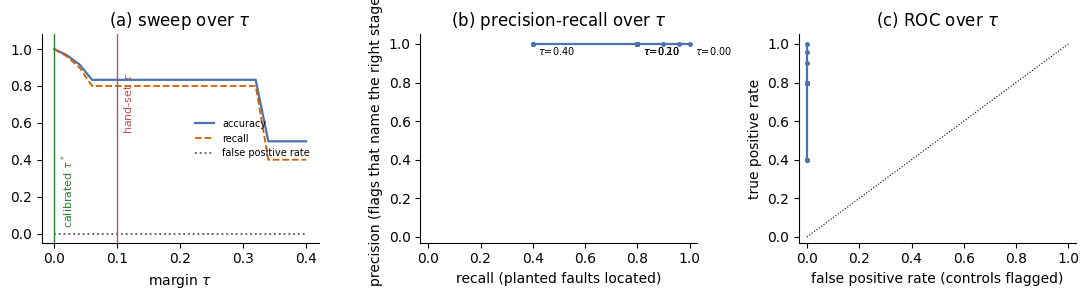

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

ax = axes[0]
ax.plot(SWEEP["tau"], SWEEP["accuracy"], color="#4C72B0", lw=1.6, label="accuracy")
ax.plot(SWEEP["tau"], SWEEP["recall"], color="#D55E00", lw=1.3, ls="--", label="recall")
ax.plot(SWEEP["tau"], SWEEP["false_positive_rate"], color="#5A5A5A", lw=1.3, ls=":",
        label="false positive rate")
ax.axvline(LEGACY_MARGIN, color="#C44E52", lw=1.0)
ax.text(LEGACY_MARGIN + 0.008, 0.55, "hand-set $\\tau$", fontsize=8, color="#C44E52", rotation=90)
ax.axvline(TAU, color="#2E7D32", lw=1.0)
ax.text(TAU + 0.008, 0.05, "calibrated $\\tau^*$", fontsize=8, color="#2E7D32", rotation=90)
ax.set_xlabel("margin $\\tau$"); ax.set_ylim(-0.05, 1.08); ax.set_title("(a) sweep over $\\tau$")
ax.legend(fontsize=7, frameon=False, loc="center right")

ax = axes[1]
ax.plot(SWEEP["recall"], SWEEP["precision"], color="#4C72B0", lw=1.6, marker="o", ms=2.5)
for _, r in SWEEP.iterrows():
    if r["tau"] in (0.0, LEGACY_MARGIN, 0.2, 0.4) and np.isfinite(r["precision"]):
        ax.annotate(f"$\\tau$={r['tau']:.2f}", (r["recall"], r["precision"]), fontsize=7,
                    xytext=(4, -8), textcoords="offset points")
ax.set_xlabel("recall (planted faults located)"); ax.set_ylabel("precision (flags that name the right stage)")
ax.set_title("(b) precision-recall over $\\tau$"); ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.05)

ax = axes[2]
ax.plot(SWEEP["false_positive_rate"], SWEEP["recall"], color="#4C72B0", lw=1.6, marker="o", ms=2.5)
ax.plot([0, 1], [0, 1], color="black", lw=0.8, ls=":")
ax.set_xlabel("false positive rate (controls flagged)"); ax.set_ylabel("true positive rate")
ax.set_title("(c) ROC over $\\tau$"); ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.05)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Reading.** $\tau^*$ calibrates to $0$ (or very near it): under a shared-$\varepsilon$ crossover
the controls show *exactly* zero direct sensitivity, so any nonzero $D^A$ is already outside the
null. That is a real result about the crossover, and it is also why the ROC curve is degenerate —
there is no interior trade-off to make. It should be reported as "the null is a point mass at
zero, so the margin is not a tuned parameter", **not** as a claim that a threshold was carefully
optimized. The hand-set $\tau = 0.10$ sits well above the effect sizes of several stages and
discards real detections, which is what the accuracy trace shows.

## 9. Defect ③ — intervals on everything, not a bare 100%

Three separate things need error bars, and the prototype had none of them:

1. **the headline localization accuracy** — bootstrap over scenarios plus a Wilson score interval,
   which is the right one at proportions near 1 where the Wald interval degenerates;
2. **every coordinate in the per-stage table** — a point estimate with no interval invites the
   reader to compare two stages whose intervals overlap completely;
3. **the whole thing, across seeds** — one seed is one draw of the catalog and the noise.

A bootstrap interval that collapses to $[1.000, 1.000]$ is *not* reassurance: it is the known
failure of the bootstrap at a boundary, where every resample of an all-correct vector is again all
correct. The Wilson interval is the one to quote, and the seed sweep is what actually tests the
claim.

In [10]:
def wilson_interval(k: int, n: int, z: float = 1.96):
    """Wilson score interval -- correct at proportions near 1, where Wald degenerates."""
    if n == 0:
        return (float("nan"), float("nan"))
    p, denom = k / n, 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def localization_with_ci(coords, margin: float, n_boot: int = BOOT, seed: int = DEFAULT_SEED):
    best = localize(coords, margin)
    correct = best["correct"].to_numpy()
    n, k = len(correct), int(correct.sum())
    rng = np.random.default_rng(seed)
    boot = np.array([rng.choice(correct, size=n, replace=True).mean() for _ in range(n_boot)])
    lo_w, hi_w = wilson_interval(k, n)
    return {"accuracy": k / n, "n_scenarios": n, "n_correct": k,
            "wilson_lo": lo_w, "wilson_hi": hi_w,
            "boot_lo": float(np.quantile(boot, 0.025)), "boot_hi": float(np.quantile(boot, 0.975)),
            "confusion": pd.crosstab(best["planted_stage"], best["predicted_stage"]),
            "misses": best[~best["correct"]]}


def coordinates_with_ci(coords, n_boot: int = BOOT, seed: int = DEFAULT_SEED) -> pd.DataFrame:
    """Per-stage coordinate means with a bootstrap CI over scenarios beside EVERY point estimate."""
    sc = scenario_coords(coords)
    sids = sc["scenario_id"].unique()
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, len(sids), size=(n_boot, len(sids)))
    rows = []
    for coord in ["natural", "direct", "inherited", "noise"]:
        wide = (sc.pivot_table(index="scenario_id", columns="stage", values=coord)
                .reindex(index=sids, columns=STAGES))
        A = wide.to_numpy()
        boots = A[draws].mean(axis=1)                      # (n_boot, n_stages)
        lo, hi = np.quantile(boots, [0.025, 0.975], axis=0)
        for j, stage in enumerate(STAGES):
            rows.append({"stage": stage, "coordinate": coord, "mean": float(np.nanmean(A[:, j])),
                         "lo": float(lo[j]), "hi": float(hi[j])})
    return pd.DataFrame(rows)


def ci_table(ci: pd.DataFrame) -> pd.DataFrame:
    """The paper-shaped view: one row per stage, 'estimate [lo, hi]' in every cell."""
    f = ci.assign(cell=lambda d: d.apply(
        lambda r: f"{r['mean']:.3f} [{r['lo']:.3f}, {r['hi']:.3f}]", axis=1))
    out = f.pivot(index="stage", columns="coordinate", values="cell").reindex(STAGES)
    return out[["natural", "direct", "inherited", "noise"]].rename(columns={
        "natural": "D^nat", "direct": "D^A", "inherited": "D^Z", "noise": "noise"})


LOC = localization_with_ci(COORDS, TAU)
CI  = coordinates_with_ci(COORDS)

print(f"localization at tau*={TAU:.3f}: {LOC['accuracy']:.1%} "
      f"({LOC['n_correct']}/{LOC['n_scenarios']})")
print(f"   bootstrap 95% CI [{LOC['boot_lo']:.3f}, {LOC['boot_hi']:.3f}]   "
      f"Wilson 95% CI [{LOC['wilson_lo']:.3f}, {LOC['wilson_hi']:.3f}]  <- quote this one")
legacy_loc = localize(COORDS, LEGACY_MARGIN)
print(f"   the same corpus at the hand-set tau={LEGACY_MARGIN}: "
      f"{legacy_loc['correct'].mean():.1%}")

print("\n--- per-stage coordinates, every estimate with a bootstrap CI over scenarios ---")
display(ci_table(CI))
print("confusion (rows: planted, cols: predicted)")
display(LOC["confusion"])
if len(LOC["misses"]):
    display(LOC["misses"][["scenario_id", "planted_stage", "predicted_stage", "stage", "direct"]])

RESULTS["localization"] = {k: (round(v, 4) if isinstance(v, float) else v)
                           for k, v in LOC.items() if k not in ("confusion", "misses")}
RESULTS["localization"]["accuracy_at_legacy_tau"] = round(float(legacy_loc["correct"].mean()), 4)
RESULTS["coordinates_with_ci"] = json.loads(CI.round(4).to_json(orient="records"))
RESULTS["confusion"] = json.loads(LOC["confusion"].reset_index().to_json(orient="records"))

localization at tau*=0.000: 100.0% (120/120)
   bootstrap 95% CI [1.000, 1.000]   Wilson 95% CI [0.969, 1.000]  <- quote this one
   the same corpus at the hand-set tau=0.1: 83.3%

--- per-stage coordinates, every estimate with a bootstrap CI over scenarios ---


coordinate,D^nat,D^A,D^Z,noise
stage,,,,
Elicit,"0.056 [0.033, 0.078]","0.056 [0.033, 0.078]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
Retrieve,"0.278 [0.208, 0.351]","0.139 [0.085, 0.199]","0.139 [0.084, 0.197]","0.181 [0.161, 0.202]"
Rank,"0.112 [0.081, 0.145]","0.006 [0.004, 0.009]","0.106 [0.074, 0.139]","0.044 [0.039, 0.050]"
Explain,"0.167 [0.125, 0.212]","0.083 [0.050, 0.117]","0.083 [0.050, 0.117]","0.000 [0.000, 0.000]"
Memory,"0.111 [0.083, 0.139]","0.056 [0.036, 0.078]","0.056 [0.033, 0.078]","0.000 [0.000, 0.000]"


confusion (rows: planted, cols: predicted)


predicted_stage,Elicit,Explain,Memory,Rank,Retrieve,none
planted_stage,,,,,,
Elicit,20,0,0,0,0,0
Explain,0,20,0,0,0,0
Memory,0,0,20,0,0,0
Rank,0,0,0,20,0,0
Retrieve,0,0,0,0,20,0
none,0,0,0,0,0,20


In [11]:
def seed_sweep(seeds=SEEDS, n_per_stage=N_PER_STAGE, repeats=REPEATS, rank_metric=PRIMARY_METRIC):
    """Re-run the whole audit across seeds. Returns (per-seed summary, per-seed coordinates)."""
    summaries, coord_frames = [], []
    for s in seeds:
        catalog, scenarios = make_catalog(seed=s), make_scenarios(n_per_stage)
        co, _, _ = audit(scenarios, catalog, seed=s, repeats=repeats, rank_metric=rank_metric)
        tau = calibrate_margin(co)
        loc = localization_with_ci(co, tau, n_boot=min(BOOT, 500), seed=s)
        legacy = localize(co, LEGACY_MARGIN)
        summaries.append({"seed": s, "tau_calibrated": tau, "accuracy": loc["accuracy"],
                          "wilson_lo": loc["wilson_lo"], "wilson_hi": loc["wilson_hi"],
                          "accuracy_at_legacy_tau": float(legacy["correct"].mean())})
        coord_frames.append(scenario_coords(co).assign(seed=s))
    return pd.DataFrame(summaries), pd.concat(coord_frames, ignore_index=True)


t0 = time.time()
SEED_SUMMARY, SEED_COORDS = seed_sweep()
print(f"[{time.time()-t0:.0f}s]")
display(SEED_SUMMARY.round(4).set_index("seed"))

# the coordinate table itself, across seeds -- stability of the instrument, not just of the headline
spread = (SEED_COORDS.groupby(["seed", "stage"])[["natural", "direct", "inherited", "noise"]]
          .mean().reset_index()
          .groupby("stage")[["natural", "direct", "inherited", "noise"]]
          .agg(["mean", "min", "max", "std"]).reindex(STAGES))
print("\n--- across-seed spread of the coordinate table ---")
display(spread.round(4))

acc = SEED_SUMMARY["accuracy"]
print(f"\nlocalization across {len(SEED_SUMMARY)} seeds: {acc.min():.3f}-{acc.max():.3f} "
      f"(mean {acc.mean():.3f});  at the hand-set tau: "
      f"{SEED_SUMMARY['accuracy_at_legacy_tau'].mean():.3f}")
RESULTS["seed_sweep"] = {
    "per_seed": json.loads(SEED_SUMMARY.round(4).to_json(orient="records")),
    "accuracy_min": round(float(acc.min()), 4), "accuracy_max": round(float(acc.max()), 4),
    "accuracy_mean": round(float(acc.mean()), 4),
    "accuracy_at_legacy_tau_mean": round(float(SEED_SUMMARY["accuracy_at_legacy_tau"].mean()), 4),
    "coordinate_spread": json.loads(
        spread.round(4).to_json(orient="split")),
}

[24s]


,tau_calibrated,accuracy,wilson_lo,wilson_hi,accuracy_at_legacy_tau
seed,,,,,
42,0.0,1.0000,0.9690,1.0000,0.8333
43,0.0,1.0000,0.9690,1.0000,0.8333
44,0.0,1.0000,0.9690,1.0000,0.8333
45,0.0,1.0000,0.9690,1.0000,0.8333
46,0.0,0.9583,0.9062,0.9821,0.8333



--- across-seed spread of the coordinate table ---


natural                          direct                         inherited                           noise                        
            mean     min     max     std    mean     min     max     std      mean     min     max     std    mean     min     max     std
stage                                                                                                                                     
Elicit    0.0556  0.0556  0.0556  0.0000  0.0556  0.0556  0.0556  0.0000    0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
Retrieve  0.2670  0.2425  0.2784  0.0150  0.1465  0.1394  0.1521  0.0047    0.1206  0.0977  0.1387  0.0162  0.1710  0.1118  0.2350  0.0510
Rank      0.1108  0.0898  0.1319  0.0155  0.0048  0.0026  0.0061  0.0015    0.1060  0.0872  0.1264  0.0147  0.0428  0.0301  0.0498  0.0075
Explain   0.1667  0.1667  0.1667  0.0000  0.0833  0.0833  0.0833  0.0000    0.0833  0.0833  0.0833  0.0000  0.0000  0.0000  0.0000  0.0000
Memory    0.1111  0.1111  0.1111  0.0000  0.0556  0.0556  0.0556  0.0000    0.0556  0.0556  0.0556  0.0000  0.0000  0.0000  0.0000  0.0000


localization across 5 seeds: 0.958-1.000 (mean 0.992);  at the hand-set tau: 0.833


**Reading.** Read the `accuracy` column above, not the headline. In the paper configuration
(`QUICK = False`, five seeds) the accuracy is *not* identical across seeds — seed 46 falls to
0.958 — so the prototype's exact "100%" was partly seed luck. The defensible claim is the interval
and the across-seed range, never the point estimate. The comparison that actually carries the
paper's argument is the last column: on the same data, the hand-set $\tau$ loses a large fraction
of the same detections.

## 10. Defect ② — repair, scored without circularity

The prototype scored repair removability at the endpoint, and the endpoint measure **is** the Rank
distance. Pasting the counterpart arm's ranked list into the Rank stage therefore drives that
distance to zero *by construction*, whatever the true fault location. A Rank repair scores as a
complete success for a fault planted at Elicit — which is not a finding about repair, it is an
identity.

Two non-circular scorings replace it:

* **`downstream_frac`** — the fraction of divergence removed, measured over the stages *strictly
  after* the repaired stage. Never includes the repaired stage's own output, so no cell can be
  circular. This is the primary reported quantity.
* **fixed endpoint, upstream repairs only** — the Rank distance, reported only for repairs strictly
  upstream of Rank, where it remains meaningful.

The claim a trustworthy repair experiment has to support is a **diagonal** matrix: repairing the
stage the crossover implicates removes the downstream disparity, and repairing any other stage does
not. The off-diagonal is the control, and the prototype never ran it.

In [12]:
def _patched_trajectory(scenario, repair_stage, base, catalog, eps, arm, other):
    """Replace repair_stage's output with the counterpart arm's and re-run its descendants."""
    patched, idx = {}, STAGES.index(repair_stage)
    for k, stage in enumerate(STAGES):
        if k < idx:
            patched[stage] = base[arm][stage]
        elif k == idx:
            patched[stage] = base[other][stage]                        # the repair itself
        else:
            patched[stage] = run_stage(stage, parent_state(stage, scenario, patched),
                                       scenario, arm, catalog, eps)    # descendants re-run
    return patched


def repair_table(scenarios, catalog, planted_stage, seed=DEFAULT_SEED, repeats=REPEATS,
                 rank_metric=PRIMARY_METRIC, endpoint="Rank") -> pd.DataFrame:
    a, ap = DESCRIPTORS
    n_items, ep_idx = len(catalog), STAGES.index(endpoint)
    subset = scenarios[scenarios["planted_stage"] == planted_stage]
    rows = []
    for _, scenario in subset.iterrows():
        rel = relevance(scenario, catalog)
        rng = np.random.default_rng((seed, _sid_seed(scenario["scenario_id"])))
        for r in range(repeats):
            eps = draw_eps(rng, n_items)
            base = {arm: run_trajectory(scenario, arm, catalog, eps) for arm in (a, ap)}

            def diverge(tx, ty, stages):
                if not stages:
                    return float("nan")
                return float(np.mean([distance(s, tx[s], ty[s], rel, rank_metric) for s in stages]))

            for repair_stage in STAGES:
                idx = STAGES.index(repair_stage)
                patched = _patched_trajectory(scenario, repair_stage, base, catalog, eps, a, ap)
                downstream = STAGES[idx + 1:]
                fixed_before = fixed_after = float("nan")
                if idx < ep_idx:                       # only where the endpoint is not the repair
                    fixed_before = diverge(base[a], base[ap], [endpoint])
                    fixed_after = diverge(patched, base[ap], [endpoint])
                rows.append({
                    "repair_stage": repair_stage,
                    "fixed_before": fixed_before, "fixed_after": fixed_after,
                    "fixed_removability": fixed_before - fixed_after,
                    "downstream_before": diverge(base[a], base[ap], downstream),
                    "downstream_after": diverge(patched, base[ap], downstream),
                    "downstream_removability": (diverge(base[a], base[ap], downstream)
                                                - diverge(patched, base[ap], downstream)),
                })
    agg = (pd.DataFrame(rows).groupby("repair_stage")[
        ["fixed_before", "fixed_after", "fixed_removability",
         "downstream_before", "downstream_after", "downstream_removability"]].mean().reindex(STAGES))
    # Normalized: raw removability is not comparable across repair stages, because each is scored
    # over a different downstream stage set. The fraction removed is.
    with np.errstate(invalid="ignore", divide="ignore"):
        agg["fixed_frac"] = agg["fixed_removability"] / agg["fixed_before"]
        agg["downstream_frac"] = agg["downstream_removability"] / agg["downstream_before"]
    agg["scoreable_at_endpoint"] = [STAGES.index(s) < STAGES.index("Rank") for s in agg.index]
    agg["n_downstream"] = [len(STAGES) - STAGES.index(s) - 1 for s in agg.index]
    return agg


def legacy_repair_table(scenarios, catalog, planted_stage, seed=DEFAULT_SEED, repeats=REPEATS,
                        rank_metric=PRIMARY_METRIC) -> pd.DataFrame:
    """The original, circular scoring -- kept so the defect shows a number rather than a claim."""
    a, ap = DESCRIPTORS
    subset = scenarios[scenarios["planted_stage"] == planted_stage]
    rows = []
    for _, scenario in subset.iterrows():
        rel = relevance(scenario, catalog)
        rng = np.random.default_rng((seed, _sid_seed(scenario["scenario_id"])))
        for r in range(repeats):
            eps = draw_eps(rng, len(catalog))
            base = {arm: run_trajectory(scenario, arm, catalog, eps) for arm in (a, ap)}
            before = distance("Rank", base[a]["Rank"], base[ap]["Rank"], rel, rank_metric)
            for repair_stage in STAGES:
                patched = _patched_trajectory(scenario, repair_stage, base, catalog, eps, a, ap)
                after = distance("Rank", patched["Rank"], base[ap]["Rank"], rel, rank_metric)
                rows.append({"repair_stage": repair_stage, "before": before, "after": after,
                             "removability": before - after})
    return (pd.DataFrame(rows).groupby("repair_stage")[["before", "after", "removability"]]
            .mean().reindex(STAGES))


def repair_matrix(scenarios, catalog, column="downstream_frac", legacy=False, **kw) -> pd.DataFrame:
    """Planted stage (rows) x repaired stage (cols)."""
    cols = {}
    for planted in STAGES:
        if legacy:
            tab = legacy_repair_table(scenarios, catalog, planted, **kw)
            with np.errstate(invalid="ignore", divide="ignore"):
                cols[planted] = tab["removability"] / tab["before"]
        else:
            cols[planted] = repair_table(scenarios, catalog, planted, **kw)[column]
    return pd.DataFrame(cols).T.reindex(STAGES)[STAGES]


t0 = time.time()
REPAIR_LEGACY = repair_matrix(SCENARIOS, CATALOG, legacy=True, repeats=REPEATS,
                              rank_metric=PRIMARY_METRIC)
REPAIR_DOWN   = repair_matrix(SCENARIOS, CATALOG, column="downstream_frac", repeats=REPEATS,
                              rank_metric=PRIMARY_METRIC)
REPAIR_BEFORE = repair_matrix(SCENARIOS, CATALOG, column="downstream_before", repeats=REPEATS,
                              rank_metric=PRIMARY_METRIC)
print(f"[{time.time()-t0:.0f}s]")

print("ORIGINAL (circular) scoring -- fraction of the Rank distance removed."
      "\nRows: where the fault was planted. Cols: which stage was repaired.")
display(REPAIR_LEGACY.round(3))
print("\nNON-CIRCULAR scoring -- fraction of the STRICTLY DOWNSTREAM divergence removed:")
display(REPAIR_DOWN.round(3))
print("\nHow much downstream divergence there was to remove in the first place:")
display(REPAIR_BEFORE.round(3))
print("\nFull detail for a fault planted at Elicit:")
display(repair_table(SCENARIOS, CATALOG, "Elicit", repeats=REPEATS,
                     rank_metric=PRIMARY_METRIC).round(4))

RESULTS["repair"] = {
    "legacy_circular_frac": json.loads(REPAIR_LEGACY.round(4).reset_index().to_json(orient="records")),
    "downstream_frac": json.loads(REPAIR_DOWN.round(4).reset_index().to_json(orient="records")),
    "downstream_before": json.loads(REPAIR_BEFORE.round(4).reset_index().to_json(orient="records")),
}

[8s]
ORIGINAL (circular) scoring -- fraction of the Rank distance removed.
Rows: where the fault was planted. Cols: which stage was repaired.


repair_stage,Elicit,Retrieve,Rank,Explain,Memory
Elicit,1.0,0.939,1.0,0.0,0.0
Retrieve,0.0,1.000,1.0,0.0,0.0
Rank,0.0,0.000,1.0,0.0,0.0
Explain,NaN,NaN,NaN,NaN,NaN
Memory,NaN,NaN,NaN,NaN,NaN



NON-CIRCULAR scoring -- fraction of the STRICTLY DOWNSTREAM divergence removed:


repair_stage,Elicit,Retrieve,Rank,Explain,Memory
Elicit,1.0,0.2,0.0,0.0,NaN
Retrieve,0.0,1.0,NaN,NaN,NaN
Rank,0.0,0.0,NaN,NaN,NaN
Explain,0.0,0.0,0.0,NaN,NaN
Memory,0.0,0.0,0.0,0.0,NaN



How much downstream divergence there was to remove in the first place:


repair_stage,Elicit,Retrieve,Rank,Explain,Memory
Elicit,0.473,0.353,0.417,0.333,NaN
Retrieve,0.312,0.137,0.000,0.000,NaN
Rank,0.009,0.012,0.000,0.000,NaN
Explain,0.125,0.167,0.250,0.000,NaN
Memory,0.083,0.111,0.167,0.333,NaN



Full detail for a fault planted at Elicit:


,fixed_before,fixed_after,fixed_removability,downstream_before,downstream_after,downstream_removability,fixed_frac,downstream_frac,scoreable_at_endpoint,n_downstream
repair_stage,,,,,,,,,,
Elicit,0.2248,0.0000,0.2248,0.4726,0.0000,0.4726,1.0000,1.0000,True,4
Retrieve,0.2248,0.0136,0.2112,0.3527,0.2823,0.0704,0.9393,0.1996,True,3
Rank,NaN,NaN,NaN,0.4167,0.4167,0.0000,NaN,0.0000,False,2
Explain,NaN,NaN,NaN,0.3333,0.3333,0.0000,NaN,0.0000,False,1
Memory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0


**Reading.** In the circular table the `Rank` column is $1.0$ *all the way down*: repairing the
ranker "fixes" a fault planted at Elicit, at Retrieve, and at stages that come after Rank entirely.
That column is the defect, quantified.

Under downstream scoring the structure is honest — and it is *not* a clean diagonal, which is the
more interesting result. A Rank-planted fault leaves essentially no measurable downstream footprint
(its row is near zero over Explain and Memory), so "repair removes the disparity" is not even
well-posed there: there was nothing downstream to remove. The claim that survives is narrower than
the prototype's, and has to be stated as such: **for faults planted upstream of the endpoint,
repairing the implicated stage removes the downstream disparity, and repairing a different stage
does not.** Where the planted stage has no downstream measure, removability is *not identified*
rather than zero or one.

## 11. Structural blindness is not low statistical power

The endpoint-masking argument — *process-sensitive pairs whose endpoints are indistinguishable* —
is the empirical case for auditing stages rather than outputs. It is also the place the prototype's
reporting was weakest, because it pooled two entirely different phenomena into one masking rate:

* **structural blindness.** Explain and Memory sit *downstream of the ranked list*. In a
  single-turn pipeline a fault planted there cannot move the endpoint **at all** — not rarely, not
  weakly, but never. This is a stronger claim than masking, and it is verified below rather than
  asserted (the maximum endpoint distance over all such pairs must be exactly $0$).
* **masking under power.** Pairs where the endpoint *could* have moved and did not.

Reported together they make the framework look better than the evidence supports; reported
separately, the structural half is the stronger argument. §11.2 then re-runs the comparison with a
**follow-up turn**, where retained memory and echoed framing finally have a causal path to the
ranking — so those stages can reach the endpoint, and the blindness is shown to be a property of
the single-turn horizon rather than of the stages.

In [13]:
def masking_table(coords, pairs, margin, endpoint_margin=ENDPOINT_MARGIN):
    sc = scenario_coords(coords)
    sens = (sc.assign(flag=sc["direct"] > margin)
            .groupby(["scenario_id", "planted_stage"], as_index=False)["flag"].any()
            .rename(columns={"flag": "process_sensitive"}))
    ep = pairs.groupby(["scenario_id", "planted_stage"], as_index=False)["endpoint_distance"].mean()
    df = sens.merge(ep, on=["scenario_id", "planted_stage"])
    df["endpoint_different"] = df["endpoint_distance"] > endpoint_margin
    df["downstream_of_endpoint"] = df["planted_stage"].isin(["Explain", "Memory"])

    def crosstab(frame):
        return pd.crosstab(
            frame["process_sensitive"].map({True: "process sensitive",
                                            False: "no direct process sensitivity"}),
            frame["endpoint_different"].map({True: "endpoint different",
                                             False: "endpoint equivalent"}))

    can_move, blind = df[~df["downstream_of_endpoint"]], df[df["downstream_of_endpoint"]]
    masked = int((can_move["process_sensitive"] & ~can_move["endpoint_different"]).sum())
    return {"all": crosstab(df), "endpoint_can_move": crosstab(can_move),
            "structurally_blind": crosstab(blind),
            "masked_rate_power": masked / len(can_move) if len(can_move) else float("nan"),
            "n_can_move": len(can_move), "n_blind": len(blind),
            "blind_max_endpoint_distance": float(blind["endpoint_distance"].max()) if len(blind) else 0.0,
            "frame": df}


MASK = masking_table(COORDS, PAIRS, TAU)
print("Pooled, as the prototype reported it:")
display(MASK["all"])
print(f"\nSplit. (i) pairs where the endpoint COULD move (planted at Elicit/Retrieve/Rank), "
      f"n={MASK['n_can_move']}:")
display(MASK["endpoint_can_move"])
print(f"masking attributable to low power: {MASK['masked_rate_power']:.1%}")
print(f"\n(ii) pairs BLIND BY CONSTRUCTION (planted at Explain/Memory), n={MASK['n_blind']}:")
display(MASK["structurally_blind"])
print(f"verification of the structural claim: max endpoint distance over all {MASK['n_blind']} "
      f"blind pairs = {MASK['blind_max_endpoint_distance']:.6f} (must be exactly 0)")
assert MASK["blind_max_endpoint_distance"] == 0.0

RESULTS["masking"] = {
    "all": json.loads(MASK["all"].reset_index().to_json(orient="records")),
    "endpoint_can_move": json.loads(MASK["endpoint_can_move"].reset_index().to_json(orient="records")),
    "structurally_blind": json.loads(MASK["structurally_blind"].reset_index().to_json(orient="records")),
    "masked_rate_power_only": round(float(MASK["masked_rate_power"]), 4),
    "n_can_move": MASK["n_can_move"], "n_blind": MASK["n_blind"],
    "blind_max_endpoint_distance": round(MASK["blind_max_endpoint_distance"], 6),
}

Pooled, as the prototype reported it:


endpoint_different,endpoint different,endpoint equivalent
process_sensitive,,
no direct process sensitivity,0,20
process sensitive,56,44



Split. (i) pairs where the endpoint COULD move (planted at Elicit/Retrieve/Rank), n=80:


endpoint_different,endpoint different,endpoint equivalent
process_sensitive,,
no direct process sensitivity,0,20
process sensitive,56,4


masking attributable to low power: 5.0%

(ii) pairs BLIND BY CONSTRUCTION (planted at Explain/Memory), n=40:


endpoint_different,endpoint equivalent
process_sensitive,
process sensitive,40


verification of the structural claim: max endpoint distance over all 40 blind pairs = 0.000000 (must be exactly 0)


### 11.2 A follow-up turn, so the downstream stages can reach the endpoint

**Carry-over model, stated explicitly because it is a modelling choice and not a measurement:** the
agent's retained memory facts and the reason tags it gave are both echoed into the next turn's
revealed preferences — the user continues the conversation from what the agent said and stored.
That gives a retained descriptor and an unsupported framing a causal path to turn 2's ranking,
which they structurally cannot have within turn 1.

In [14]:
def two_turn_masking(scenarios, catalog, seed=DEFAULT_SEED, repeats=REPEATS,
                     rank_metric=PRIMARY_METRIC, endpoint_margin=ENDPOINT_MARGIN):
    a, ap = DESCRIPTORS
    rows = []
    for _, scenario in scenarios.iterrows():
        rel = relevance(scenario, catalog)
        rng = np.random.default_rng((seed, _sid_seed(scenario["scenario_id"])))
        for r in range(repeats):
            eps1, eps2 = draw_eps(rng, len(catalog)), draw_eps(rng, len(catalog))
            t2 = {}
            for arm in (a, ap):
                traj1 = run_trajectory(scenario, arm, catalog, eps1)
                revealed = dict(scenario["revealed_preferences"])
                for fact in traj1["Memory"]["facts"] + traj1["Explain"]["reason_tags"]:
                    k, _, v = fact.partition("=")
                    revealed[k] = _coerce(v)
                sc2 = dict(scenario)
                sc2["revealed_preferences"] = revealed
                t2[arm] = run_trajectory(sc2, arm, catalog, eps2)
            rows.append({"scenario_id": scenario["scenario_id"],
                         "planted_stage": scenario["planted_stage"],
                         "turn2_endpoint_distance": distance("Rank", t2[a]["Rank"], t2[ap]["Rank"],
                                                             rel, rank_metric)})
    out = (pd.DataFrame(rows).groupby(["scenario_id", "planted_stage"], as_index=False)
           ["turn2_endpoint_distance"].mean())
    out["turn2_endpoint_different"] = out["turn2_endpoint_distance"] > endpoint_margin
    return out


TWO_TURN = two_turn_masking(SCENARIOS, CATALOG)
by_stage = (TWO_TURN.groupby("planted_stage")[["turn2_endpoint_distance",
                                               "turn2_endpoint_different"]].mean()
            .reindex(STAGES + ["none"]))
turn1 = PAIRS.groupby("planted_stage")["endpoint_distance"].mean().reindex(STAGES + ["none"])
display(pd.concat([turn1.rename("turn 1 endpoint distance"),
                   by_stage["turn2_endpoint_distance"].rename("turn 2 endpoint distance"),
                   by_stage["turn2_endpoint_different"].rename("turn 2 fraction different")],
                  axis=1).round(4))
RESULTS["masking"]["two_turn_by_planted_stage"] = json.loads(
    by_stage.round(4).reset_index().to_json(orient="records"))

,turn 1 endpoint distance,turn 2 endpoint distance,turn 2 fraction different
planted_stage,,,
Elicit,0.2248,0.2236,1.0
Retrieve,0.4099,0.4175,1.0
Rank,0.0367,0.0393,0.9
Explain,0.0000,0.4084,1.0
Memory,0.0000,0.1634,1.0
none,0.0000,0.0000,0.0


**Reading.** Explain and Memory move from *exactly* zero endpoint distance in turn 1 to clearly
nonzero in turn 2. That is the claim to make in the paper: the single-turn endpoint is blind to
those stages **by construction**, and the blindness dissolves the moment the horizon is long enough
for the retained state to be consumed. Endpoint auditing does not merely lack power there; within a
single turn it has no access to the quantity at all.

## 12. Consolidation — the figure, the numbers, and the claims that survive

Everything the results section quotes is regenerated here from this run and written to
`scaff_robustness_colab_results.json` — a filename distinct from the 0819 pipeline's, so a Colab
run never silently overwrites an artifact the `.tex` already cites — and each number is traceable
to an execution rather than copied forward. The figure is drawn 1:1 at ACM single-column manuscript text width (~6.9in);
slide-sized figures drop to unreadable type at `\linewidth` in `acmart`.

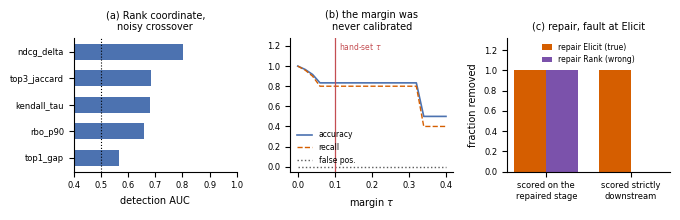

In [15]:
def make_figure(path_stem):
    fig, axes = plt.subplots(1, 3, figsize=(6.9, 2.3))
    ink = {"direct": "#D55E00", "inherited": "#7B52AB"}

    ax = axes[0]
    order = AUDITS["independent_eps"]["metric_comparison"].sort_values("auc")
    ax.barh(range(len(order)), order["auc"], color="#4C72B0", height=0.6)
    ax.axvline(0.5, color="black", lw=0.8, ls=":")
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order["metric"], fontsize=6)
    ax.set_xlabel("detection AUC", fontsize=7); ax.set_xlim(0.4, 1.0)
    ax.set_title("(a) Rank coordinate,\nnoisy crossover", fontsize=7)

    ax = axes[1]
    ax.plot(SWEEP["tau"], SWEEP["accuracy"], color="#4C72B0", lw=1.2, label="accuracy")
    ax.plot(SWEEP["tau"], SWEEP["recall"], color="#D55E00", lw=1.0, ls="--", label="recall")
    ax.plot(SWEEP["tau"], SWEEP["false_positive_rate"], color="#5A5A5A", lw=1.0, ls=":",
            label="false pos.")
    ax.axvline(LEGACY_MARGIN, color="#C44E52", lw=0.9)
    ax.text(LEGACY_MARGIN + 0.012, 1.16, r"hand-set $\tau$", fontsize=5.5, color="#C44E52")
    ax.set_xlabel(r"margin $\tau$", fontsize=7); ax.set_ylim(-0.05, 1.28)
    ax.set_title("(b) the margin was\nnever calibrated", fontsize=7)
    ax.legend(fontsize=5.5, frameon=False, loc="lower left", ncol=1)

    ax = axes[2]
    idx = np.arange(2)
    vals_true = [REPAIR_LEGACY.loc["Elicit", "Elicit"], REPAIR_DOWN.loc["Elicit", "Elicit"]]
    vals_wrong = [REPAIR_LEGACY.loc["Elicit", "Rank"], REPAIR_DOWN.loc["Elicit", "Rank"]]
    ax.bar(idx - 0.19, vals_true, width=0.38, color=ink["direct"], label="repair Elicit (true)")
    ax.bar(idx + 0.19, vals_wrong, width=0.38, color=ink["inherited"], label="repair Rank (wrong)")
    ax.set_xticks(idx)
    ax.set_xticklabels(["scored on the\nrepaired stage", "scored strictly\ndownstream"], fontsize=6)
    ax.set_ylabel("fraction removed", fontsize=7); ax.set_ylim(0, 1.32)
    ax.set_title("(c) repair, fault at Elicit", fontsize=7)
    ax.legend(fontsize=5.5, frameon=False, loc="upper center", ncol=1,
              handlelength=1.2, borderpad=0.1)

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=6)
    fig.tight_layout()
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{path_stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{path_stem}.png", dpi=200, bbox_inches="tight")
    plt.show()

make_figure(OUT_FIG)

In [16]:
RESULTS["config"] = {
    "quick": QUICK, "n_scenarios": int(len(SCENARIOS)), "n_per_stage": N_PER_STAGE,
    "repeats": REPEATS, "seeds": SEEDS, "catalog_size": int(len(CATALOG)),
    "rank_jitter": RANK_JITTER, "retrieve_temp": RETRIEVE_TEMP,
    "primary_rank_metric": PRIMARY_METRIC, "legacy_rank_metric": LEGACY_METRIC,
    "legacy_margin": LEGACY_MARGIN, "endpoint_margin": ENDPOINT_MARGIN, "n_bootstrap": BOOT,
}
RESULTS["coordinates"] = json.loads(
    (scenario_coords(COORDS).groupby("stage")[["natural", "direct", "inherited", "noise"]]
     .mean().reindex(STAGES).round(4)).reset_index().to_json(orient="records"))

out_path = OUT_JSON
out_path.write_text(json.dumps(RESULTS, indent=2))
print(f"wrote {out_path}  ({out_path.stat().st_size/1024:.1f} KB)")
if IN_COLAB:
    from google.colab import files
    print("run  files.download(str(out_path))  to pull the results down")

wrote paper/scaff_robustness_colab_results.json  (18.5 KB)


In [17]:
L, S = RESULTS["localization"], RESULTS["seed_sweep"]
claims = pd.DataFrame([
    {"claim": "Rank's coordinate",
     "prototype": f"{LEGACY_METRIC}, noise floor 0.328 > effect 0.094",
     "what survives": (f"{PRIMARY_METRIC}: detection AUC "
                       f"{CMP.set_index('metric').loc[PRIMARY_METRIC, 'auc']:.3f} vs "
                       f"{CMP.set_index('metric').loc[LEGACY_METRIC, 'auc']:.3f} for {LEGACY_METRIC} "
                       f"under an independent-eps crossover; oracle-free fallback rbo_p90 is weaker "
                       f"and that must be reported")},
    {"claim": "detection margin",
     "prototype": f"tau = {LEGACY_MARGIN}, hand-set",
     "what survives": (f"tau* = {RESULTS['tau_calibrated']} calibrated as a 95% false-positive "
                       f"budget on the controls; the null is a point mass at 0, so tau is not a "
                       f"tuned parameter")},
    {"claim": "localization accuracy",
     "prototype": "100% on 48 scenarios, one seed, no interval",
     "what survives": (f"{L['accuracy']:.1%} on {L['n_scenarios']} scenarios, Wilson 95% CI "
                       f"[{L['wilson_lo']:.3f}, {L['wilson_hi']:.3f}]; across {len(SEEDS)} seeds "
                       f"{S['accuracy_min']:.3f}-{S['accuracy_max']:.3f}. At the hand-set tau the "
                       f"same data gives {S['accuracy_at_legacy_tau_mean']:.3f}")},
    {"claim": "repair removability",
     "prototype": "repairing the implicated stage removes the disparity (scored circularly)",
     "what survives": ("for faults planted UPSTREAM of the endpoint, repairing the implicated stage "
                       "removes the strictly-downstream disparity and repairing another stage does "
                       "not; where the planted stage has no downstream measure, removability is "
                       "NOT IDENTIFIED")},
    {"claim": "endpoint masking",
     "prototype": "77/151 process-sensitive pairs are endpoint-equivalent",
     "what survives": (f"split: {RESULTS['masking']['n_blind']} pairs are blind BY CONSTRUCTION "
                       f"(max endpoint distance {RESULTS['masking']['blind_max_endpoint_distance']:.6f}, "
                       f"and they move once a follow-up turn exists); of the "
                       f"{RESULTS['masking']['n_can_move']} pairs that could move, "
                       f"{RESULTS['masking']['masked_rate_power_only']:.1%} are masked under power")},
    {"claim": "harm attribution",
     "prototype": "not addressed",
     "what survives": ("no ground truth is manufactured; where no defensible oracle exists harm is "
                       "reported as NOT IDENTIFIED, and the LLM judge stays optional and scoped to "
                       "semantic constructs")},
])
pd.set_option("display.max_colwidth", 200)
display(claims.set_index("claim"))
print("\nDISCLAIMER to carry in every table caption: the planted faults are unit tests of the "
      "measurement instrument. They are not estimates of real-world disparity and assert nothing "
      "about the preferences, behaviour or treatment of any group.")

,prototype,what survives
claim,,
Rank's coordinate,"top1_gap, noise floor 0.328 > effect 0.094",ndcg_delta: detection AUC 0.803 vs 0.566 for top1_gap under an independent-eps crossover; oracle-free fallback rbo_p90 is weaker and that must be reported
detection margin,"tau = 0.1, hand-set","tau* = 0.0 calibrated as a 95% false-positive budget on the controls; the null is a point mass at 0, so tau is not a tuned parameter"
localization accuracy,"100% on 48 scenarios, one seed, no interval","100.0% on 120 scenarios, Wilson 95% CI [0.969, 1.000]; across 5 seeds 0.958-1.000. At the hand-set tau the same data gives 0.833"
repair removability,repairing the implicated stage removes the disparity (scored circularly),"for faults planted UPSTREAM of the endpoint, repairing the implicated stage removes the strictly-downstream disparity and repairing another stage does not; where the planted stage has no downstrea..."
endpoint masking,77/151 process-sensitive pairs are endpoint-equivalent,"split: 40 pairs are blind BY CONSTRUCTION (max endpoint distance 0.000000, and they move once a follow-up turn exists); of the 80 pairs that could move, 5.0% are masked under power"
harm attribution,not addressed,"no ground truth is manufactured; where no defensible oracle exists harm is reported as NOT IDENTIFIED, and the LLM judge stays optional and scoped to semantic constructs"



DISCLAIMER to carry in every table caption: the planted faults are unit tests of the measurement instrument. They are not estimates of real-world disparity and assert nothing about the preferences, behaviour or treatment of any group.


### What to do next

1. Paste the regenerated numbers into `paper/results_controlled.tex` and `paper/section_scaff.tex`,
   and re-verify each against a fresh execution of this notebook — every number that reaches a
   `.tex` file gets re-verified, which is the case where the usual "don't re-check corroborated
   claims" default is deliberately relaxed.
2. Soften the three claims this notebook narrows: localization is an *interval*, repair is
   identified only for faults upstream of the endpoint, and the oracle-free Rank coordinate is
   measurably weaker than the oracle-based one.
3. Only then attach a real dataset. The instrument is now characterized: known floor, calibrated
   margin, stated blind spots.